# Rafael TCC - Projeto 04
## Análise Estatística Descritiva

Análise Exploratória dos dados de touros Nelore presentes na plataforma CRV, segundo o programa de melhoramento

### Bibliotecas

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### Leitura dos dados

In [3]:
programa = 'ANCP'
df_valid = pd.read_csv(f'Dados/CSV/NeloreCRV_{programa}_valido.csv')

### Análise selos comerciais da crv

In [4]:
# PASSO 1: Identificar todos os selos únicos
selos = set()
for item in df_valid['SELOS'].dropna():
    selos_linha = [s.strip().lower() for s in str(item).split(';') if s.strip()]
    selos.update(selos_linha)

selos = set(map(str.upper, selos))
selos = sorted(list(selos))

print(f"Total de selos identificados: {len(selos)}")
print("Selos encontrados:", selos)

Total de selos identificados: 16
Selos encontrados: ['ATJ-PLUS', 'CAR', 'CARCACA-3-ESTRELAS', 'CARCACA-4-ESTRELAS', 'CARCACA-5-ESTRELAS', 'EXTENSIVO', 'IFERT', 'MATERNAL', 'NOVILHAS', 'PESO', 'PNAT', 'PO', 'REPRODUTIVO', 'RP-ANCP', 'SEMIEXTENSIVO', 'SEMIINTENSIVO']


In [5]:
# Criar novo dataframe com colunas de 1 ou 0 para cada selo
df_selos = df_valid[['CRV_COD', 'NOME', 'RACA', 'RGD', 'DNASC', 'SEMEM']].copy()

for selo in selos:
    # Nome padonizado para a coluna: ex: SELO_IFERT, SELO_CARCACA_5_ESTRELAS
    nome_coluna = 'SELO_' + selo.replace('-', '_')
    
    # Preenche com 1 se o selo estiver no texto da coluna, 0 caso contrário
    df_selos[nome_coluna] = df_valid['SELOS'].apply(
        lambda x: 1 if pd.notna(x) and selo in [s.strip().upper() for s in str(x).split(';')] else 0
    )

In [6]:
# Frequência dos selos e Preço Médio por presença do selo

colunas_selos = [c for c in df_selos.columns if c.startswith('SELO_')]

resumo_selos = []
for col in colunas_selos:
    n_com = (df_selos[col] == 1).sum()
    pct_com = (n_com / len(df_selos)) * 100
    media_com = df_selos.loc[df_selos[col] == 1, 'SEMEM'].mean()
    media_sem = df_selos.loc[df_selos[col] == 0, 'SEMEM'].mean()
    dif_preco = media_com - media_sem
    
    resumo_selos.append({
        'Selo': col,
        'N_Touros': n_com,
        '% Touros': round(pct_com, 1),
        'Preço Médio COM (R$)': round(media_com, 2),
        'Preço Médio SEM (R$)': round(media_sem, 2),
        'Diferença (R$)': round(dif_preco, 2)
    })

df_resumo = pd.DataFrame(resumo_selos).sort_values(by='N_Touros', ascending=False)
df_resumo.reset_index(drop=True, inplace=True)
df_resumo


,Selo,N_Touros,% Touros,Preço Médio COM (R$),Preço Médio SEM (R$),Diferença (R$)
0,SELO_PO,115,100.0,32.40,NaN,NaN
1,SELO_PESO,96,83.5,32.31,32.85,-0.53
2,SELO_REPRODUTIVO,80,69.6,32.36,32.50,-0.14
3,SELO_MATERNAL,76,66.1,33.15,30.95,2.20
4,SELO_SEMIINTENSIVO,62,53.9,32.24,32.58,-0.34
5,SELO_CAR,56,48.7,33.36,31.49,1.86
6,SELO_SEMIEXTENSIVO,51,44.3,32.36,32.43,-0.07
7,SELO_IFERT,46,40.0,35.90,30.07,5.84
8,SELO_CARCACA_5_ESTRELAS,42,36.5,33.64,31.69,1.95
9,SELO_CARCACA_4_ESTRELAS,32,27.8,32.09,32.52,-0.43


#### Avaliação de ágio de preço por selo comercial (com selo vs sem selo)

In [7]:
# Calcular o Ágio para cada selo (mínimo de 5 touros com o selo para ter validade)
colunas_selos = [c for c in df_selos.columns if c.startswith('SELO_')]

resultados_selos = []

for selo in colunas_selos:
    com_selo = df_selos[df_selos[selo] == 1]['SEMEM']
    sem_selo = df_selos[df_selos[selo] == 0]['SEMEM']
    
    n_com = len(com_selo)
    n_sem = len(sem_selo)
    
    # Considerar apenas selos com representatividade mínima (>= 5 animais)
    if n_com >= 5 and n_sem >= 5:
        media_com = com_selo.mean()
        media_sem = sem_selo.mean()
        mediana_com = com_selo.median()
        mediana_sem = sem_selo.median()
        
        agio_reais = media_com - media_sem
        agio_pct = ((media_com / media_sem) - 1) * 100
        
        # Teste t de Student para testar diferença estatística entre as médias
        t_stat, p_val = stats.ttest_ind(com_selo, sem_selo, equal_var=False)
        
        resultados_selos.append({
            'Selo Comercial': selo.upper(),
            'N_Com_Selo': n_com,
            'N_Sem_Selo': n_sem,
            'Preço Médio COM (R$)': round(media_com, 2),
            'Preço Médio SEM (R$)': round(media_sem, 2),
            'Mediana COM (R$)': round(mediana_com, 2),
            'Mediana SEM (R$)': round(mediana_sem, 2),
            'Ágio (R$)': round(agio_reais, 2),
            'Ágio (%)': round(agio_pct, 1),
            'p-valor': round(p_val, 4)
        })

df_agio_selos = pd.DataFrame(resultados_selos).sort_values(by='Ágio (R$)', ascending=False).reset_index(drop=True)

# Adicionar formatação de significância
def rotulo_p(p):
    if p < 0.01: return '*** (Signif. 1%)'
    if p < 0.05: return '** (Signif. 5%)'
    if p < 0.10: return '* (Signif. 10%)'
    return 'Não significativo'

df_agio_selos['Significância'] = df_agio_selos['p-valor'].apply(rotulo_p)

print("=" * 100)
print("RANKING DE VALORIZAÇÃO DOS SELOS COMERCIAIS NA CRV (ÁGIO: COM SELO vs SEM SELO)")
print("=" * 100)
display(df_agio_selos)

RANKING DE VALORIZAÇÃO DOS SELOS COMERCIAIS NA CRV (ÁGIO: COM SELO vs SEM SELO)


,Selo Comercial,N_Com_Selo,N_Sem_Selo,Preço Médio COM (R$),Preço Médio SEM (R$),Mediana COM (R$),Mediana SEM (R$),Ágio (R$),Ágio (%),p-valor,Significância
0,SELO_IFERT,46,69,35.90,30.07,33.9,31.2,5.84,19.4,0.0000,*** (Signif. 1%)
1,SELO_NOVILHAS,29,86,34.18,31.80,33.9,31.2,2.38,7.5,0.1140,Não significativo
2,SELO_MATERNAL,76,39,33.15,30.95,31.2,31.2,2.20,7.1,0.0801,* (Signif. 10%)
3,SELO_CARCACA_5_ESTRELAS,42,73,33.64,31.69,31.2,31.2,1.95,6.1,0.1299,Não significativo
4,SELO_CAR,56,59,33.36,31.49,31.8,31.2,1.86,5.9,0.1416,Não significativo
5,SELO_RP_ANCP,7,108,33.40,32.34,31.2,31.2,1.06,3.3,0.6720,Não significativo
6,SELO_SEMIEXTENSIVO,51,64,32.36,32.43,31.2,31.2,-0.07,-0.2,0.9553,Não significativo
7,SELO_REPRODUTIVO,80,35,32.36,32.50,31.2,33.9,-0.14,-0.4,0.9238,Não significativo
8,SELO_SEMIINTENSIVO,62,53,32.24,32.58,31.2,31.2,-0.34,-1.0,0.7902,Não significativo
9,SELO_CARCACA_4_ESTRELAS,32,83,32.09,32.52,31.2,31.2,-0.43,-1.3,0.7812,Não significativo


#### Gráfico de barras: ágio de preço por selo comercial

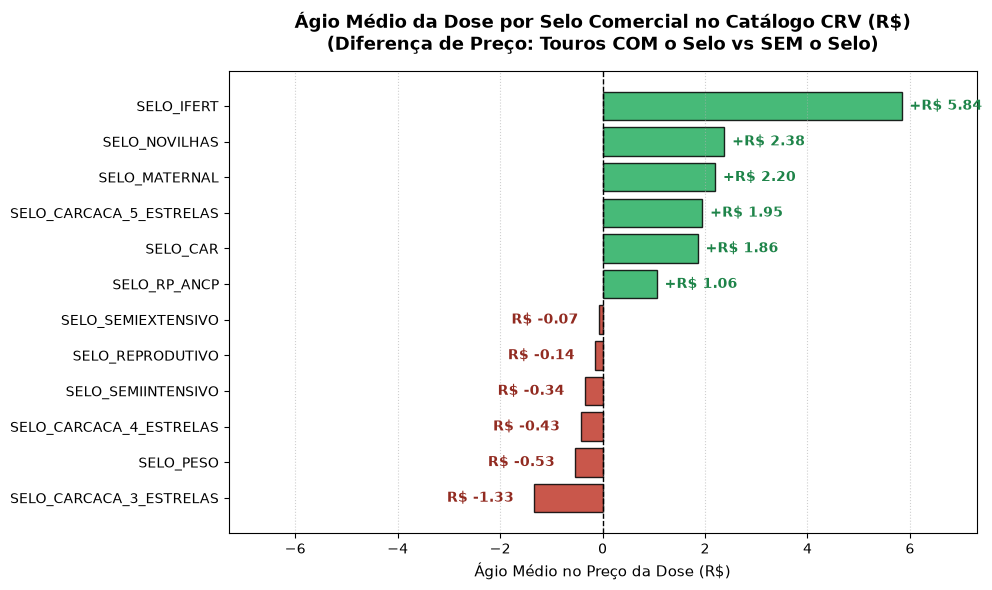

In [8]:
plt.figure(figsize=(10, 6))

cores_graf = ['#27ae60' if x >= 0 else '#c0392b' for x in df_agio_selos['Ágio (R$)'][::-1]]
barras = plt.barh(df_agio_selos['Selo Comercial'][::-1], df_agio_selos['Ágio (R$)'][::-1], 
                  color=cores_graf, edgecolor='black', alpha=0.85)

for b in barras:
    w = b.get_width()
    sinal = "+" if w >= 0 else ""
    plt.text(w + (0.15 if w>=0 else -0.4), b.get_y() + b.get_height()/2, f"{sinal}R$ {w:.2f}", 
             va='center', ha='left' if w>=0 else 'right', fontsize=10, fontweight='bold', 
             color='#1e8449' if w>=0 else '#922b21')

plt.title("Ágio Médio da Dose por Selo Comercial no Catálogo CRV (R$)\n(Diferença de Preço: Touros COM o Selo vs SEM o Selo)", 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Ágio Médio no Preço da Dose (R$)", fontsize=11)
lim_x = max(abs(df_agio_selos['Ágio (R$)'].min()), abs(df_agio_selos['Ágio (R$)'].max())) * 1.25
plt.xlim(-lim_x, lim_x)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()